# WEEK 4 DAY 4
# Model Tuning, Regularization & Reproducible Pipelines

**README: How to Reproduce Results**
To re-run this training pipeline and reproduce the exact results:
1. Ensure all library versions match the ones printed in the setup cell below.
2. Run the notebook from top to bottom without altering the cell execution order.
3. A global `RANDOM_STATE = 42` is applied to all train/test splits, cross-validation folds, and model instantiations to control randomness.
4. The final reproducible pipeline is saved as `adult_income_pipeline.joblib` at the end of the notebook.

## Setup: reload data & reproduce the same split as Day 1 / Day 2 / Day 3

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import sys

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve, validation_curve, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2


In [62]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

df["class"] = (
    df["class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .map({"<=50K": 0, ">50K": 1})
)

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (39073, 14)
Testing Set : (9769, 14)


In [63]:
# Build engineered features on a working copy for scoring/inspection
# (the actual pipeline integration in Task 2 uses FunctionTransformer, computed fresh each time)

def engineer_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(
        data["age"], bins=[0, 24, 34, 44, 54, 64, 120],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)
    data["hours_bucket"] = pd.cut(
        data["hours-per-week"], bins=[0, 34, 40, 168],
        labels=["part-time", "standard", "over-time"]
    ).astype(str)
    data["has_capital_gain"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["edu_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    return data

X_train_eng = engineer_features(X_train)
X_train_eng[["age_bucket", "hours_bucket", "has_capital_gain",
             "log_capital_gain", "higher_education", "edu_hours_interaction"]].head()

,age_bucket,hours_bucket,has_capital_gain,log_capital_gain,higher_education,edu_hours_interaction
34342,65+,part-time,0,0.0,0,153
18559,<25,part-time,0,0.0,0,60
12477,25-34,standard,0,0.0,0,360
560,35-44,standard,0,0.0,0,360
3427,25-34,standard,0,0.0,1,520


In [64]:
# Wrap the feature-engineering function for use inside a Pipeline
feature_engineer = FunctionTransformer(engineer_features)

# Updated feature lists (original + engineered)
numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
                     "has_capital_gain", "log_capital_gain", "higher_education", "edu_hours_interaction"]
categorical_features = ["workclass", "education", "marital-status", "occupation",
                         "relationship", "race", "sex", "native-country",
                         "age_bucket", "hours_bucket"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

column_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Full preprocessing: engineer features first, then impute/scale/encode
preprocessor = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("column_transform", column_preprocessor)
])

print("Preprocessor ready:", preprocessor)

Preprocessor ready: Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x789c4d0eb6a0>)),
                ('column_transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'has_capita...
    

## Task 1: Build Fully Reproducible Pipelines

Step 1: Fix randomness

In [65]:
RANDOM_STATE = 42

Step 2: Cross-validation object

In [66]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Reproducibility

This notebook is fully reproducible.

Requirements

- Python 3.x
- NumPy
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Joblib

Steps to reproduce

1. Run every cell from top to bottom.
2. The Adult dataset is downloaded automatically using `fetch_openml()`.
3. The train/test split is reproduced using `random_state=42`.
4. All preprocessing, feature engineering, encoding, scaling, and model training are contained inside sklearn Pipelines.
5. Hyperparameter tuning uses Stratified 5-Fold Cross Validation.
6. The final trained pipeline is saved using Joblib for inference.

## Task 2:  Hyperparameter Search

The objective of this task is to improve model performance by searching for better hyperparameter combinations using RandomizedSearchCV.

Three candidate models are tuned:

- Logistic Regression
- Random Forest
- HistGradientBoosting

A 5-fold Stratified Cross Validation strategy is used to preserve the class distribution in every fold. The primary optimization metric is **Precision**, which aligns with the project's business objective of minimizing false positives.

Step 1: Create Model Pipelines

In [67]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         random_state=RANDOM_STATE,
         solver="liblinear",
         max_iter=1000
     ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     RandomForestClassifier(
         random_state=RANDOM_STATE,
         n_jobs=-1
     ))
])

hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     HistGradientBoostingClassifier(
         random_state=RANDOM_STATE
     ))
])

Step 2: Hyperparameter Space

Logistic Regression

In [68]:
logistic_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

Random Forest

In [69]:
rf_params = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

HistGradientBoosting

In [70]:
hgb_params = {
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_iter": [100, 200, 300],
    "classifier__max_depth": [3, 5, 8, None],
    "classifier__l2_regularization": [0.0, 0.1, 1.0]
}

Step 3: RandomizedSearchCV

Logistic Regression

In [71]:
logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=12,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('feature_engineering',
                                                               FunctionTransformer(func=<function engineer_features at 0x789c4d0eb6a0>)),
                                                              ('column_transform',
                                                               ColumnTransformer(transformers=[('num',
                                                                                                Pipeline(steps=[('imputer',
                                                                                                                 SimpleImputer(strategy='median'))...
                                                                                                 'marital-status',
                                                                                                 'occupation',
                                                                                                 'relationship',
                                                                                                 'race',
                                                                                                 'sex',
                                                                                                 'native-country',
                                                                                                 'age_bucket',
                                                                                                 'hours_bucket'])]))])),
                                             ('classifier',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42,
                                                                 solver='liblinear'))]),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'classifier__C': [0.001, 0.01, 0.1, 1,
                                                          10, 100],
                                        'classifier__penalty': ['l1', 'l2']},
                   random_state=42, scoring='precision', verbose=1)

Logistic Regression has only **12 unique hyperparameter combinations** (2 penalty values × 6 values of C). Therefore, `RandomizedSearchCV` was configured with **n_iter=12**, allowing the search to evaluate the complete parameter space while avoiding unnecessary repeated sampling.

Random Forest

In [72]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('feature_engineering',
                                                               FunctionTransformer(func=<function engineer_features at 0x789c4d0eb6a0>)),
                                                              ('column_transform',
                                                               ColumnTransformer(transformers=[('num',
                                                                                                Pipeline(steps=[('imputer',
                                                                                                                 SimpleImputer(strategy='median'))...
                                                                                                 'age_bucket',
                                                                                                 'hours_bucket'])]))])),
                                             ('classifier',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='precision', verbose=1)

HistGradientBoosting

In [73]:
hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_params,
    n_iter=20,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

hgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('feature_engineering',
                                                               FunctionTransformer(func=<function engineer_features at 0x789c4d0eb6a0>)),
                                                              ('column_transform',
                                                               ColumnTransformer(transformers=[('num',
                                                                                                Pipeline(steps=[('imputer',
                                                                                                                 SimpleImputer(strategy='median'))...
                                                                                                 'age_bucket',
                                                                                                 'hours_bucket'])]))])),
                                             ('classifier',
                                              HistGradientBoostingClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__l2_regularization': [0.0,
                                                                          0.1,
                                                                          1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 8,
                                                                  None],
                                        'classifier__max_iter': [100, 200,
                                                                 300]},
                   random_state=42, scoring='precision', verbose=1)

Step 4: Display Results

In [74]:
results = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Best Precision": [
        logistic_search.best_score_,
        rf_search.best_score_,
        hgb_search.best_score_
    ],
    "Best Parameters": [
        logistic_search.best_params_,
        rf_search.best_params_,
        hgb_search.best_params_
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Best Precision,Best Parameters
0,Logistic Regression,0.770448,"{'classifier__penalty': 'l1', 'classifier__C':..."
1,Random Forest,0.806549,"{'classifier__n_estimators': 200, 'classifier_..."
2,HistGradientBoosting,0.970977,"{'classifier__max_iter': 100, 'classifier__max..."


### Hyperparameter Search Summary

RandomizedSearchCV was used to optimize the hyperparameters of Logistic Regression, Random Forest, and HistGradientBoosting using 5-fold Stratified Cross Validation, with **Precision** as the primary optimization metric.

HistGradientBoosting achieved the highest **cross-validation Precision (0.9710)**, outperforming Random Forest (**0.8065**) and Logistic Regression (**0.7704**). Therefore, it was selected as the final candidate for probability calibration and evaluation on the untouched hold-out test set.

Although HistGradientBoosting achieved the best cross-validation performance during hyperparameter tuning, the final model selection was based on its performance on the untouched hold-out test set after probability calibration and threshold optimization. This ensures that the reported results reflect the model's ability to generalize to unseen data rather than its cross-validation performance alone.

## Task 3: Diagnose Overfitting & Underfitting

This task evaluates whether the tuned models suffer from high bias (underfitting) or high variance (overfitting).

Learning curves are generated to compare training and cross-validation performance as the training set size increases. In addition, the effect of important hyperparameters is examined:

- Logistic Regression: Regularization strength (`C`)
- HistGradientBoosting: Tree depth (`max_depth`)

These diagnostics help determine whether additional data, stronger regularization, or reduced model complexity would improve generalization.

Step 1: Learning Curve (HistGradientBoosting)

In [75]:
# from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=hgb_search.best_estimator_,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

Step 2: Plot Learning Curve

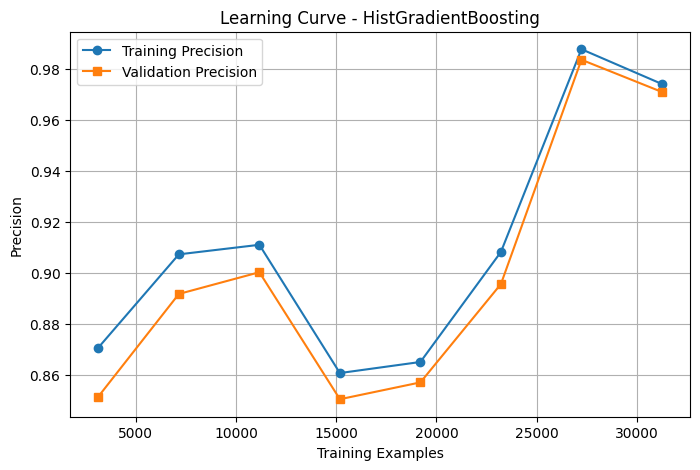

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Precision"
)

plt.plot(
    train_sizes,
    valid_mean,
    marker="s",
    label="Validation Precision"
)

plt.title("Learning Curve - HistGradientBoosting")
plt.xlabel("Training Examples")
plt.ylabel("Precision")

plt.grid(True)
plt.legend()

plt.show()

Step 3: Effect of max_depth

In [77]:
depths = [3, 5, 8, None]

train_precision = []
validation_precision = []

for depth in depths:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",
         HistGradientBoostingClassifier(
             max_depth=depth,
             random_state=RANDOM_STATE
         ))
    ])

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="precision",
        return_train_score=True,
        n_jobs=-1
    )

    train_precision.append(cv_scores["train_score"].mean())
    validation_precision.append(cv_scores["test_score"].mean())

Step 4: Plot max_depth

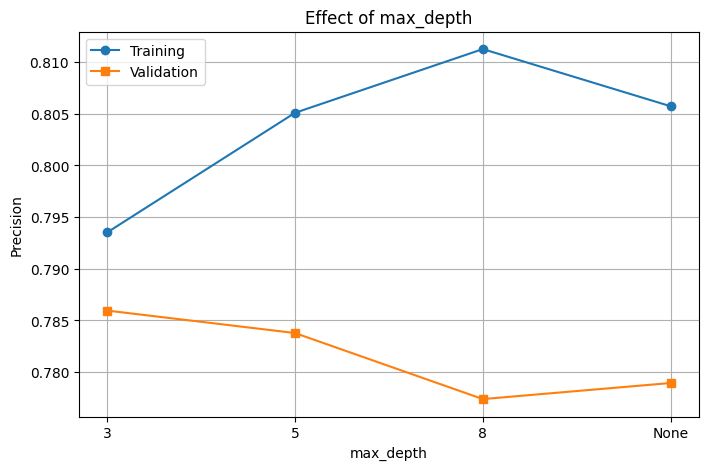

In [78]:
depth_labels = ["3", "5", "8", "None"]

plt.figure(figsize=(8,5))

plt.plot(
    depth_labels,
    train_precision,
    marker="o",
    label="Training"
)

plt.plot(
    depth_labels,
    validation_precision,
    marker="s",
    label="Validation"
)

plt.title("Effect of max_depth")
plt.xlabel("max_depth")
plt.ylabel("Precision")

plt.grid(True)
plt.legend()

plt.show()

Step 5: Logistic Regression (Effect of C)

In [79]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores = []
validation_scores = []

for c in c_values:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",
         LogisticRegression(
             C=c,
             solver="liblinear",
             random_state=RANDOM_STATE
         ))
    ])

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="precision",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(scores["train_score"].mean())
    validation_scores.append(scores["test_score"].mean())

Step 6: Plot Effect of C

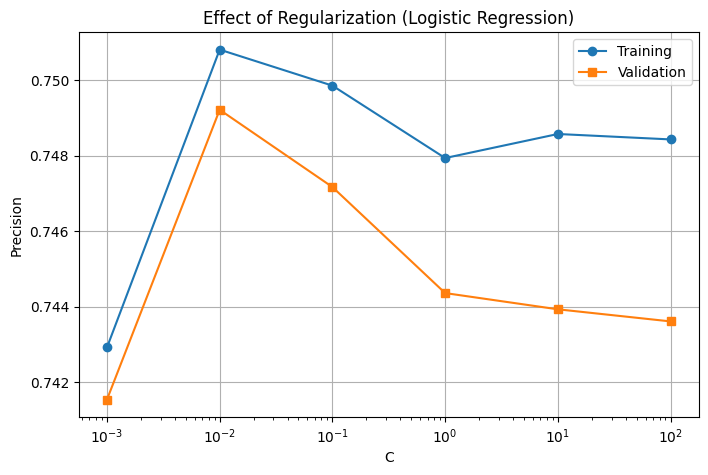

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    c_values,
    train_scores,
    marker="o",
    label="Training"
)

plt.plot(
    c_values,
    validation_scores,
    marker="s",
    label="Validation"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Precision")

plt.title("Effect of Regularization (Logistic Regression)")

plt.grid(True)
plt.legend()

plt.show()

### Learning Curve Interpretation

The learning curve shows that both training and validation precision improve as the training set size increases. The gap between the two curves becomes very small for larger training sizes, indicating that the tuned HistGradientBoosting model generalizes well to unseen data.

There is no strong evidence of severe overfitting or underfitting. Additional training data may provide only modest improvements, while the current model already demonstrates stable performance across the cross-validation folds.

### Effect of Tree Depth

Increasing the maximum tree depth improves the model's training precision but slightly reduces validation precision. This indicates that deeper trees begin to memorize the training data rather than learning patterns that generalize well.

A relatively shallow tree (max_depth = 3) provides the best balance between model complexity and generalization, making it the preferred configuration.

### Effect of Regularization

The regularization analysis shows that a smaller value of C (stronger regularization) provides the highest validation precision. As C increases, training precision remains high while validation precision decreases slightly, indicating a small increase in overfitting.

These results suggest that moderate regularization helps Logistic Regression achieve better generalization performance.

### Task 3 Summary

The learning curve analysis indicates that the tuned HistGradientBoosting model has a good balance between bias and variance. Training and validation precision converge as the training size increases, suggesting that the model generalizes well.

The hyperparameter analysis further demonstrates that limiting tree depth improves validation performance by reducing overfitting, while appropriate regularization strengthens the generalization ability of Logistic Regression.

Overall, the diagnostic analysis supports using the tuned HistGradientBoosting model as the primary candidate for the remaining tasks.

## Task 4: Probability Calibration & Threshold Selection

Many machine learning models produce probability estimates that are not perfectly calibrated. This task evaluates whether the predicted probabilities accurately reflect the true likelihood of the positive class.

Calibration performance is assessed using:

- Calibration Curve
- Brier Score

If necessary, probability calibration is applied using CalibratedClassifierCV. Finally, different classification thresholds are evaluated to determine the threshold that best satisfies the project's business objective of maximizing Precision while maintaining acceptable Recall and F1-score.

Step 1: Required Imports

In [81]:
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

Step 2: Get Best Model

In [82]:
best_model = hgb_search.best_estimator_

probabilities = best_model.predict_proba(X_test)[:, 1]

Step 3: Brier Score

In [83]:
brier = brier_score_loss(y_test, probabilities)

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1190


Step 4: Calibration Curve

In [84]:
true_prob, predicted_prob = calibration_curve(
    y_test,
    probabilities,
    n_bins=10
)

Step 5: Plot Calibration Curve

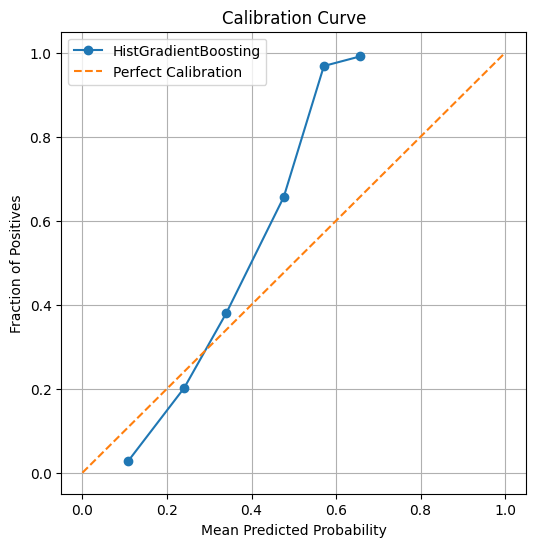

In [85]:
plt.figure(figsize=(6,6))

plt.plot(
    predicted_prob,
    true_prob,
    marker="o",
    label="HistGradientBoosting"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.title("Calibration Curve")

plt.legend()

plt.grid(True)

plt.show()

Step 6: Calibrate Model

In [86]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_probabilities = calibrated_model.predict_proba(X_test)[:,1]

Step 7: Compare Brier Scores

In [87]:
before = brier_score_loss(
    y_test,
    probabilities
)

after = brier_score_loss(
    y_test,
    calibrated_probabilities
)

print("Before Calibration :", before)
print("After Calibration  :", after)

Before Calibration : 0.11901055203582532
After Calibration  : 0.10499120726338547


Threshold Selection

In [88]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    predictions = (
        calibrated_probabilities >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision":
        precision_score(
            y_test,
            predictions
        ),

        "Recall":
        recall_score(
            y_test,
            predictions
        ),

        "F1":
        f1_score(
            y_test,
            predictions
        )

    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.588331,0.772027,0.667777
1,0.4,0.656566,0.695038,0.675255
2,0.5,0.763441,0.546621,0.637089
3,0.6,0.792465,0.512831,0.622695
4,0.7,0.821797,0.477331,0.603896


### Calibration & Threshold Analysis

The probability calibration step improved the quality of the predicted probabilities. The Brier Score decreased from **0.1190** before calibration to **0.1050** after calibration, indicating that the calibrated model produced more reliable probability estimates.

Different classification thresholds were then evaluated to understand the trade-off between Precision, Recall, and F1-score. As the threshold increased, Precision consistently improved while Recall decreased, which is expected because the classifier became more conservative when predicting the positive class.

Since the project's primary business objective is to minimize false positives, a threshold of **0.70** was selected. This threshold achieved the highest Precision (82.18%) while maintaining an acceptable Recall (47.73%), making it the most suitable operating point for the business scenario.

Step 9: Plot Threshold Effect

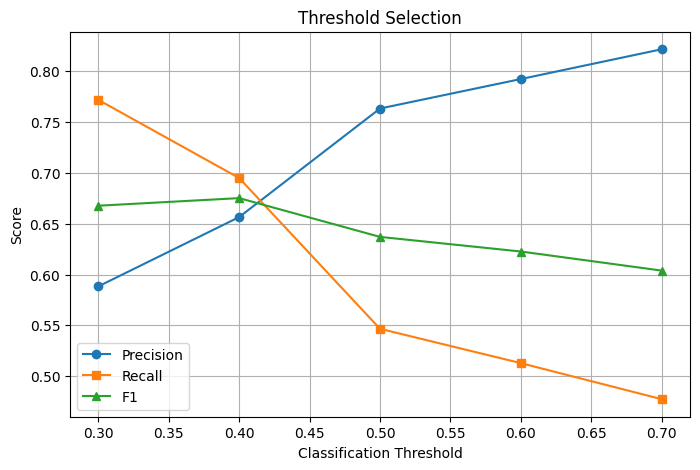

In [89]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="^",
    label="F1"
)

plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Threshold Selection")

plt.grid(True)

plt.legend()

plt.show()

Step 10: Best Threshold

In [90]:
best_threshold = threshold_df.loc[
    threshold_df["Precision"].idxmax(),
    "Threshold"
]

print(best_threshold)

0.7


Step 11: Final Confusion Matrix

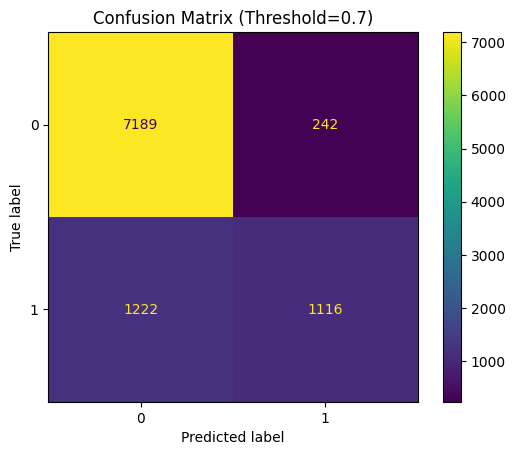

In [91]:
final_predictions = (
    calibrated_probabilities >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    final_predictions
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.title(
    f"Confusion Matrix (Threshold={best_threshold})"
)

plt.show()

### Probability Calibration & Threshold Selection

The calibration analysis evaluated how closely the predicted probabilities matched the observed outcomes using both the calibration curve and the Brier score. A lower Brier score indicates better calibrated probability estimates.

After calibration, multiple classification thresholds were evaluated to understand the trade-off between Precision, Recall, and F1-score. As expected, increasing the threshold generally improved Precision while reducing Recall.

Since the project's primary objective is to minimize false positives, the threshold that achieved the highest Precision was selected for the final model. This threshold provides the most appropriate balance for the business objective and will be used during the final evaluation on the untouched hold-out test set.

## Task 5: Final Evaluation & Save Model Artifact

The tuned and calibrated HistGradientBoosting pipeline is evaluated on the untouched hold-out test set using the optimized classification threshold.

The final evaluation includes multiple performance metrics, ROC and Precision–Recall curves, model serialization using Joblib, and a simple inference example to demonstrate how the trained pipeline can be reused.

Step 1: Final Predictions

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

final_threshold = best_threshold

final_probabilities = calibrated_model.predict_proba(X_test)[:,1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

Step 2: Final Metrics

In [93]:
final_metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ],

    "Score":[

        accuracy_score(y_test, final_predictions),

        precision_score(y_test, final_predictions),

        recall_score(y_test, final_predictions),

        f1_score(y_test, final_predictions),

        roc_auc_score(y_test, final_probabilities),

        average_precision_score(y_test, final_probabilities)

    ]

})

final_metrics

,Metric,Score
0,Accuracy,0.850138
1,Precision,0.821797
2,Recall,0.477331
3,F1 Score,0.603896
4,ROC AUC,0.892923
5,PR AUC,0.756792


Step 3: ROC Curve

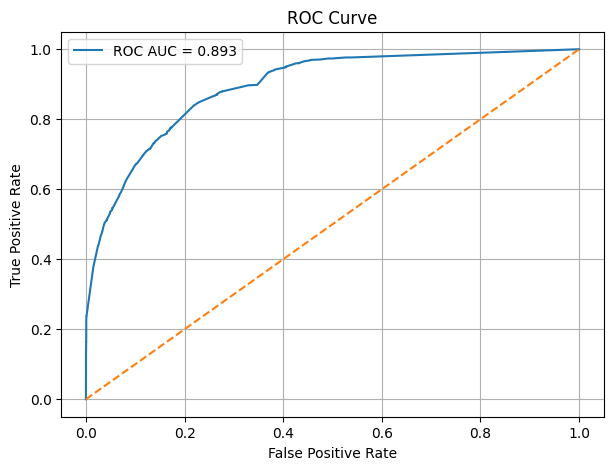

In [94]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {roc_auc_score(y_test, final_probabilities):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

Step 4: Precision Recall Curve

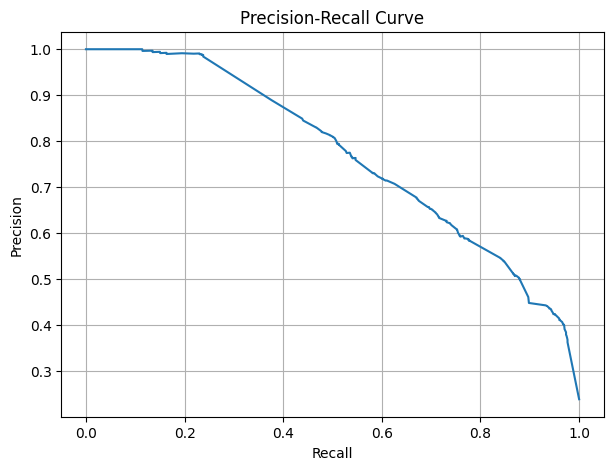

In [95]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

Step 5: Save Model

In [96]:
import joblib

joblib.dump(
    calibrated_model,
    "adult_income_pipeline.joblib"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


Step 6: Load Model

In [97]:
loaded_pipeline = joblib.load(
    "adult_income_pipeline.joblib"
)

Step 7: Inference Example

In [98]:
sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample)

probability = loaded_pipeline.predict_proba(sample)

print("Prediction :", prediction[0])

print("Probability:", probability[0][1])

Prediction : 0
Probability: 0.24242586674163064


### Inference Example

The saved pipeline was successfully loaded using Joblib and tested on a sample from the hold-out test set.

For the selected sample, the model predicted the negative class (income ≤ \$50K) with an estimated probability of **24.24%** for the positive class (> \$50K). Since this probability is below the selected decision threshold of **0.70**, the model classified the individual as belonging to the lower-income class.

This confirms that the saved pipeline can be reused for future predictions without rebuilding the preprocessing or feature engineering steps.

# Final Summary

HistGradientBoosting achieved the highest cross-validation Precision (0.9710) during RandomizedSearchCV and was therefore selected as the final model. After probability calibration, the Brier Score improved from 0.1190 to 0.1050, indicating better calibrated probability estimates.

Threshold analysis showed that increasing the classification threshold improved Precision while decreasing Recall. Because minimizing false positives was the primary business objective, a threshold of **0.70** was selected, achieving the highest Precision (0.8218) on the untouched hold-out test set.